In [1]:
import kagglehub
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt


c:\Users\hongy\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Figure size 640x480 with 0 Axes>

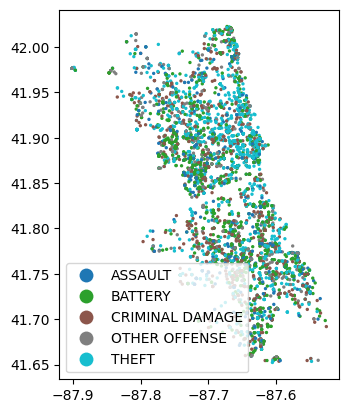

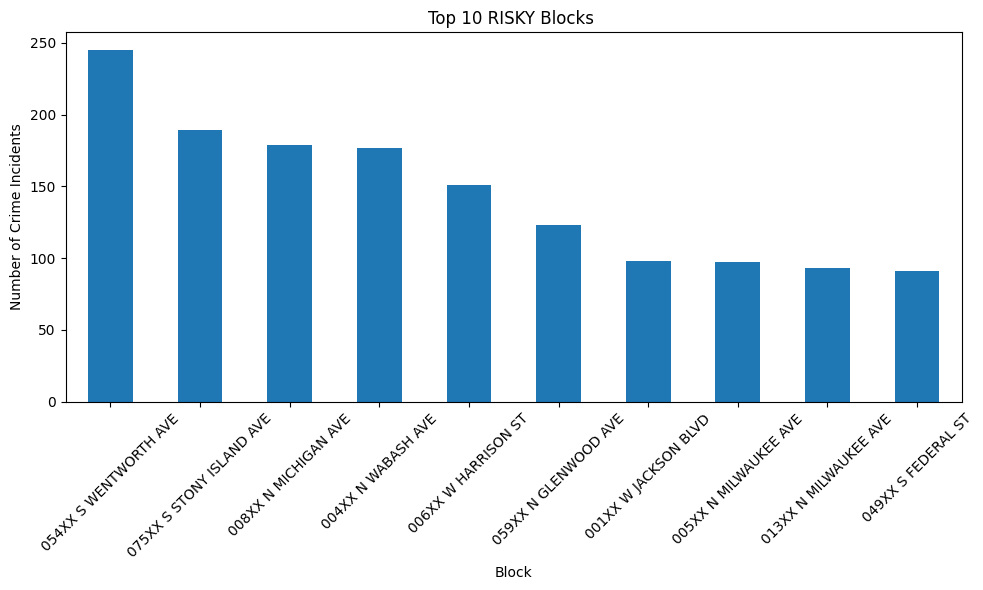

count    20000.000000
mean      2013.700900
std          6.635875
min       2001.000000
25%       2014.000000
50%       2016.000000
75%       2018.000000
max       2023.000000
Name: Year, dtype: float64

In [2]:
df = pd.read_csv(r'C:\CSE163\eda\Crimes_-_2001_to_Present.csv',nrows=20000)


"""
convert x cor and y coor into lat&long
"""
df_temp = df.dropna(subset=["X Coordinate", "Y Coordinate"])
gdf = gpd.GeoDataFrame(df_temp,geometry=gpd.points_from_xy(df_temp["X Coordinate"], df_temp["Y Coordinate"]),
crs= 'EPSG:3435')
gdf = gdf.to_crs(epsg=4326)

top_five = gdf["Primary Type"].value_counts().head(5).index #too many types, get
#the first 5
gdf = gdf[gdf["Primary Type"].isin(top_five)]
plt.figure()
gdf.sample(5000).plot(
    column="Primary Type",
    legend=True,
    markersize=2
)
# top 10 blocks criminally frequent
block_counts = df["Block"].value_counts().head(10)

block_counts
plt.figure(figsize=(10,6))
block_counts.plot(kind="bar")
plt.title("Top 10 RISKY Blocks ")
plt.xlabel("Block")
plt.ylabel("Number of Crime Incidents")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

df["Year"].describe() #number of crime increases every year in general

In [3]:
tier1_tourism_crimes = [
    'ROBBERY',
    'THEFT',
    'BATTERY',
    'ASSAULT'
]

tier2_tourism_crimes = [
    'BURGLARY',
    'MOTOR VEHICLE THEFT',
    'CRIM SEXUAL ASSAULT',
    'CRIMINAL SEXUAL ASSAULT',
    'KIDNAPPING',
    'STALKING',
    'HUMAN TRAFFICKING'
]

In [4]:
gdf_tier1 = gdf[gdf['Primary Type'].isin(tier1_tourism_crimes)]
gdf_tier2 = gdf[gdf['Primary Type'].isin(tier2_tourism_crimes)]

In [7]:
from scipy.stats import gaussian_kde
import numpy as np

✅ 已保存: chicago_tier_heatmap.png


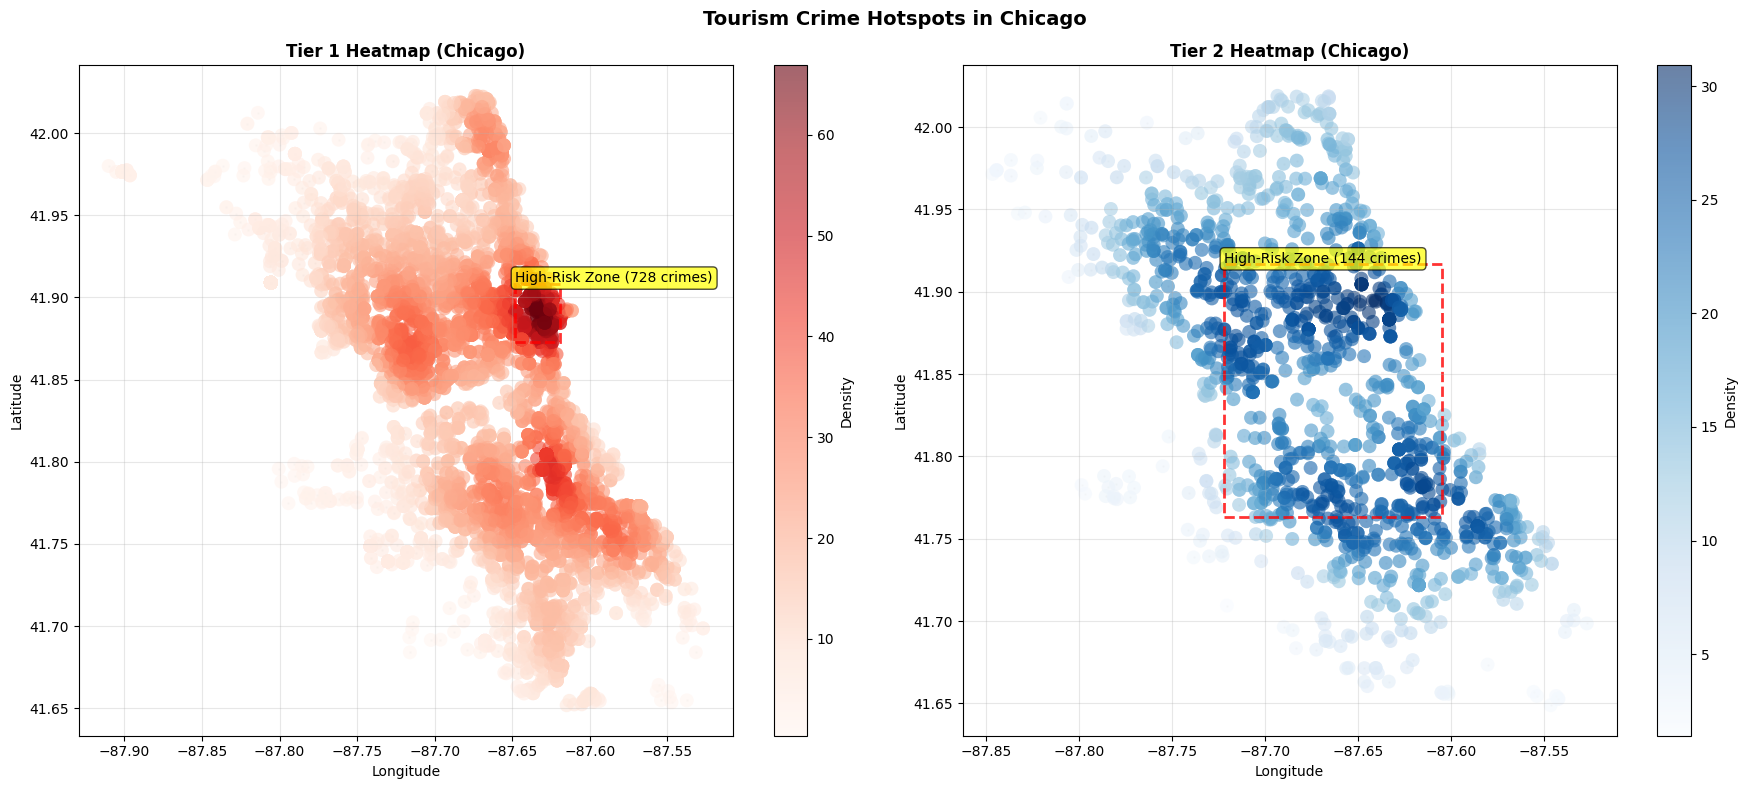

In [13]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# 加载数据
df = pd.read_csv(r'C:\CSE163\eda\Crimes_-_2001_to_Present.csv', nrows=20000)
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')

# Tier定义
tier1 = ['ROBBERY', 'THEFT', 'BATTERY', 'ASSAULT']
tier2 = ['BURGLARY', 'MOTOR VEHICLE THEFT', 'CRIM SEXUAL ASSAULT', 'CRIMINAL SEXUAL ASSAULT', 'KIDNAPPING', 'STALKING', 'HUMAN TRAFFICKING']

# 过滤和转换坐标
df_tier1 = df[df['Primary Type'].isin(tier1)].dropna(subset=['X Coordinate', 'Y Coordinate'])
df_tier2 = df[df['Primary Type'].isin(tier2)].dropna(subset=['X Coordinate', 'Y Coordinate'])

gdf_tier1 = gpd.GeoDataFrame(df_tier1, geometry=gpd.points_from_xy(df_tier1['X Coordinate'], df_tier1['Y Coordinate']), crs='EPSG:3435').to_crs(epsg=4326)
gdf_tier2 = gpd.GeoDataFrame(df_tier2, geometry=gpd.points_from_xy(df_tier2['X Coordinate'], df_tier2['Y Coordinate']), crs='EPSG:3435').to_crs(epsg=4326)

# 画图
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

from matplotlib.patches import Rectangle

for ax, gdf, tier_name, color in [(axes[0], gdf_tier1, 'Tier 1', 'Reds'),
                                   (axes[1], gdf_tier2, 'Tier 2', 'Blues')]:
    # 背景: 所有犯罪点
    ax.scatter(gdf.geometry.x, gdf.geometry.y, alpha=0.05, color='gray', s=1)
    
    # 热力图: 大圆圈
    xy = np.vstack([gdf.geometry.x, gdf.geometry.y])
    z = gaussian_kde(xy)(xy)
    
    scatter = ax.scatter(gdf.geometry.x, gdf.geometry.y, c=z, s=100, cmap=color, alpha=0.6, edgecolors='none')
    plt.colorbar(scatter, ax=ax, label='Density')
    
    # 框出高危地区 (密度最高的区域)
    threshold = np.percentile(z, 90)
    high_risk_mask = z >= threshold
    high_risk_count = high_risk_mask.sum()
    
    if high_risk_count > 0:
        # 计算高危区域的边界
        high_risk_lons = gdf.geometry.x.values[high_risk_mask]
        high_risk_lats = gdf.geometry.y.values[high_risk_mask]
        
        min_lat, max_lat = high_risk_lats.min(), high_risk_lats.max()
        min_lon, max_lon = high_risk_lons.min(), high_risk_lons.max()
        
        # 画方框
        rect = Rectangle((min_lon, min_lat), max_lon - min_lon, max_lat - min_lat,
                        linewidth=2, edgecolor='red', facecolor='none', linestyle='--', alpha=0.8)
        ax.add_patch(rect)
        
        # 标注
        ax.text(min_lon, max_lat + 0.001, f'High-Risk Zone ({high_risk_count} crimes)', 
               fontsize=10, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    
    ax.set_title(f'{tier_name} Heatmap (Chicago)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(alpha=0.3)

plt.suptitle('Tourism Crime Hotspots in Chicago', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chicago_tier_heatmap.png', dpi=300, bbox_inches='tight')
print("✅ 已保存: chicago_tier_heatmap.png")
plt.show()